### Disease and Age Distribution

This notebook is for visulaizing the orignal data set before processing has been done.
we aim to look a prevalent question: Is there a significant correlation between age and the incidence of eye diseases such as Glaucoma, Cataract, or Age-related Macular Degeneration? 

Our analysis, provides a twofold understanding. Firstly, to understand the age distribution amongst the different eye conditions within our dataset. Secondly, to uncover age-specific trends in the prevalence of these diseases. By going into this visual exposition, we intend to shed light on the relationship between age and ocular diseases in our dataset


### Install required libraries

In [1]:
!pip install opendatasets

Defaulting to user installation because normal site-packages is not writeable


### Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od

### Download dataset

In [5]:
od.download(
    "https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k")

Skipping, found downloaded files in ".\ocular-disease-recognition-odir5k" (use force=True to force download)


Read Downloaded Images and Display them

> This tells me there might be repeated files so i'll take a look at the full data

In [6]:
original_dataframe = pd.read_excel("../ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/data.xlsx")

### Inspect Data

In [7]:
original_dataframe.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [8]:
original_dataframe.columns

Index(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus',
       'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G',
       'C', 'A', 'H', 'M', 'O'],
      dtype='object')

### Check for duplicates and missing values

In [9]:
duplicateRows = original_dataframe[original_dataframe.duplicated()]

In [10]:
len(original_dataframe)

3500

> - No duplicate Rows
> - From the length we can tell we should be expecting 7000 images (i.e. 2 eyes per individual)
> - This shows that from the length of the training and testing there are 1000 images shared between those folders. 
>We should confirm this and then decide on a better split between training and testing images.

In [11]:
# Check for missing values
print(original_dataframe.isnull().sum())

ID                           0
Patient Age                  0
Patient Sex                  0
Left-Fundus                  0
Right-Fundus                 0
Left-Diagnostic Keywords     0
Right-Diagnostic Keywords    0
N                            0
D                            0
G                            0
C                            0
A                            0
H                            0
M                            0
O                            0
dtype: int64


    Theres no missing values, we've checked to established that maybe some rows might be null resulting in the  count being distorted. 


 ### Age Distribution
    Here we visualize the distribution of ages across the data set using a histogram.

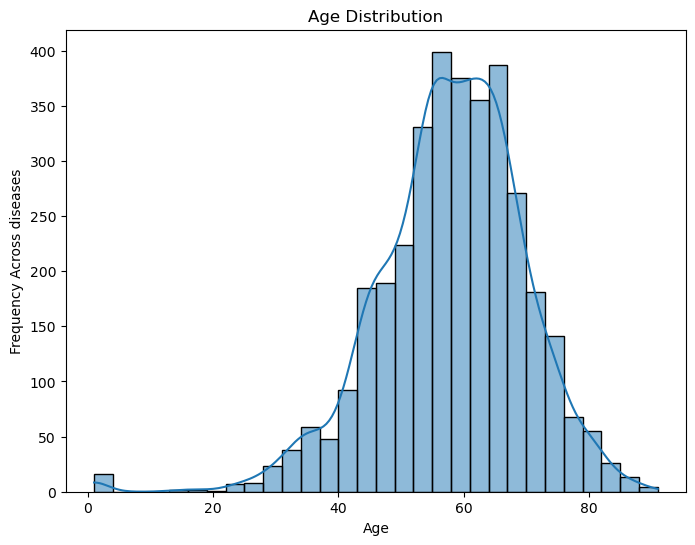

In [12]:
# Histogram of ages
plt.figure(figsize=(8,6 ))
sns.histplot(original_dataframe['Patient Age'], bins=30, kde=True #'kde=True' adds Kernel Density Estimate line to smooth the histogram
)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency Across diseases')
plt.show()

    From the visulization above, we are able to see that ages between 40-60 appears most frequently in this data set.

### Disease Condition Distribution

    For binary disease condition flags like N, D, G etc , we've sum up each column to get the count of positive cases.

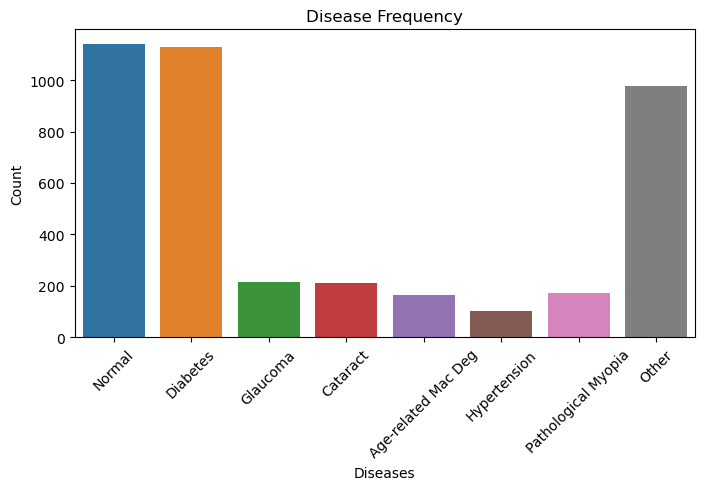

In [13]:
condition_aliases = {
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'Age-related Mac Deg',
    'H': 'Hypertension',
    'M': 'Pathological Myopia',
    'O': 'Other'
}

# Count of each condition
condition_counts = original_dataframe[['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']].sum()

# labeliing based on the aliases
condition_names = [condition_aliases[key] for key in condition_counts.index]

plt.figure(figsize=(8,4))
sns.barplot(x=condition_names, y= condition_counts.values)
plt.title('Disease Frequency')
plt.xlabel('Diseases')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.show()

    based on the bar chart above, weve been able to identify and see the distribution(count) of the eyes labels in this data set.

### Creating a distribution for most common diseases among different age groups 

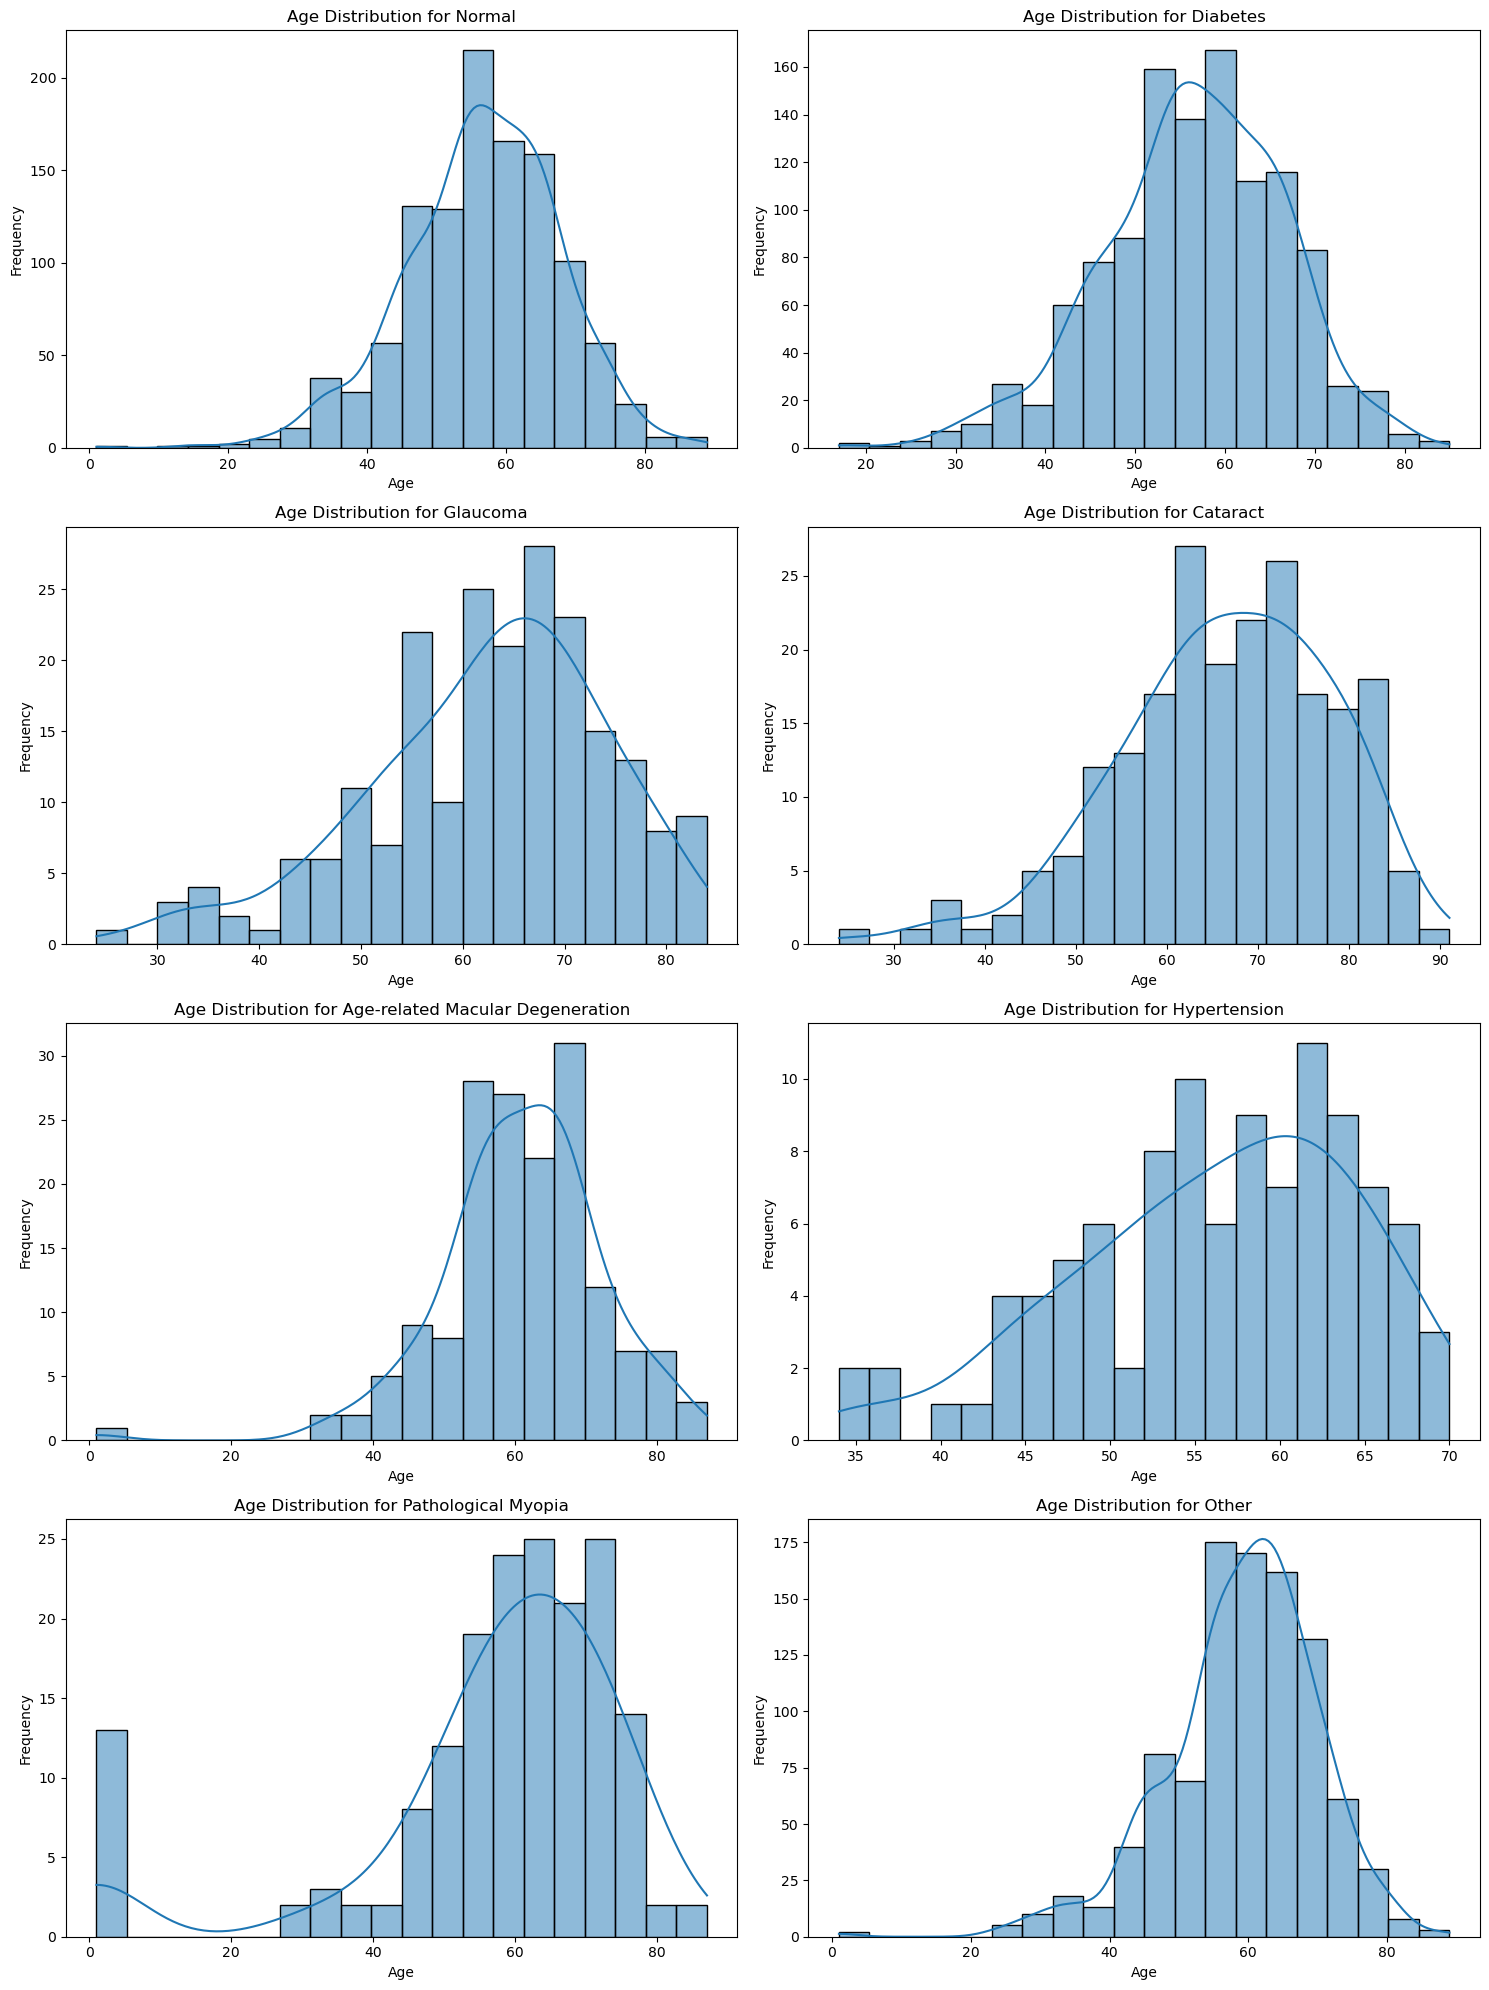

In [14]:
# The conditions and their full names
conditions = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
condition_names = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age-related Macular Degeneration', 'Hypertension', 'Pathological Myopia', 'Other']

# Create a figure and a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))

# Flatten the grid of subplots for easier iteration
axes = axes.flatten()

# Plot each condition
for i, condition in enumerate(conditions):
    sns.histplot(original_dataframe[original_dataframe[condition] == 1]['Patient Age'], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Age Distribution for {condition_names[i]}')
    axes[i].set_xlabel('Age')
    axes[i].set_ylabel('Frequency')

# Remove any remaining unused subplots
for i in range(len(conditions), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


### Analysis 

If you take a close look at the dataset, each eye has a diagnostic keyword, and though we intend to visualize the count of these diagnostics, we can't because the data has not yet been processed so here we visualize the count and distribution of labels because they are much more consistent to be visualized. The post processed data is available in the Post-processing Age Distribution file.

Generally, most diseases are present between 45+. There is a spike around 0+ for pathological myopia. This we believe is synonymous with the early development cycle of children. It is surprising that there is no such case between that spike and 20+ but we believe this is likely the result of the sample this data was collected from. Age related macular degeneration & Hypertension have the strongest grouping around 40+ as is the nature of those diseases.